# Round 3 — Delta-1 Analysis

Analysis of the two delta-1 products in Round 3: `HYDROGEL_PACK` and
`VELVETFRUIT_EXTRACT`. VELVETFRUIT_EXTRACT is also the underlying of the 10
VEV vouchers — see `analysis_options.ipynb`.

See `DESIGN.md` for the notebook outline.

## A. Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import helpers

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "Data"))
OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), "output"))
os.makedirs(OUTPUT_DIR, exist_ok=True)

PRICE_FILES = [
    "prices_round_3_day_0.csv",
    "prices_round_3_day_1.csv",
    "prices_round_3_day_2.csv",
]
TRADE_FILES = [
    "trades_round_3_day_0.csv",
    "trades_round_3_day_1.csv",
    "trades_round_3_day_2.csv",
]

DELTA1_PRODUCTS = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VISIBLE_LEVELS = 3
HORIZON = 10

In [3]:
prices_all = helpers.load_prices(DATA_DIR, PRICE_FILES)
trades_all = helpers.load_trades(DATA_DIR, TRADE_FILES)

prices = prices_all[prices_all["product"].isin(DELTA1_PRODUCTS)].copy()
trades = trades_all[trades_all["product"].isin(DELTA1_PRODUCTS)].copy()

book = helpers.build_book_features(prices)
trade_agg, raw_trades = helpers.build_trade_features(trades, book)
df = helpers.merge_book_and_trade(book, trade_agg)

print(f"book rows       : {len(book):>7,}")
print(f"trade agg rows  : {len(trade_agg):>7,}")
print(f"raw trade rows  : {len(raw_trades):>7,}")
print(f"merged df rows  : {len(df):>7,}")

book rows       :  60,000
trade agg rows  :   2,373
raw trade rows  :   2,382
merged df rows  :  60,000


### A.5 Data quality summary

In [4]:
qc = (df.groupby(["product", "day"])
        .agg(rows=("timestamp", "size"),
             nan_mid=("mid_price", lambda s: s.isna().sum()),
             zero_mid=("mid_price", lambda s: (s == 0).sum()))
        .reset_index())
display(qc)

bad_mask = df["mid_price"] == 0
print(f"zero-mid rows: {bad_mask.sum()}  ({100*bad_mask.mean():.3f}%)")
df_clean = df[~bad_mask].copy()

,product,day,rows,nan_mid,zero_mid
0,HYDROGEL_PACK,0,10000,0,0
1,HYDROGEL_PACK,1,10000,0,0
2,HYDROGEL_PACK,2,10000,0,0
3,VELVETFRUIT_EXTRACT,0,10000,0,0
4,VELVETFRUIT_EXTRACT,1,10000,0,0
5,VELVETFRUIT_EXTRACT,2,10000,0,0


zero-mid rows: 0  (0.000%)


## B. Cross-product overview

Both products plotted together across the three days to spot regime shifts
and coupling.

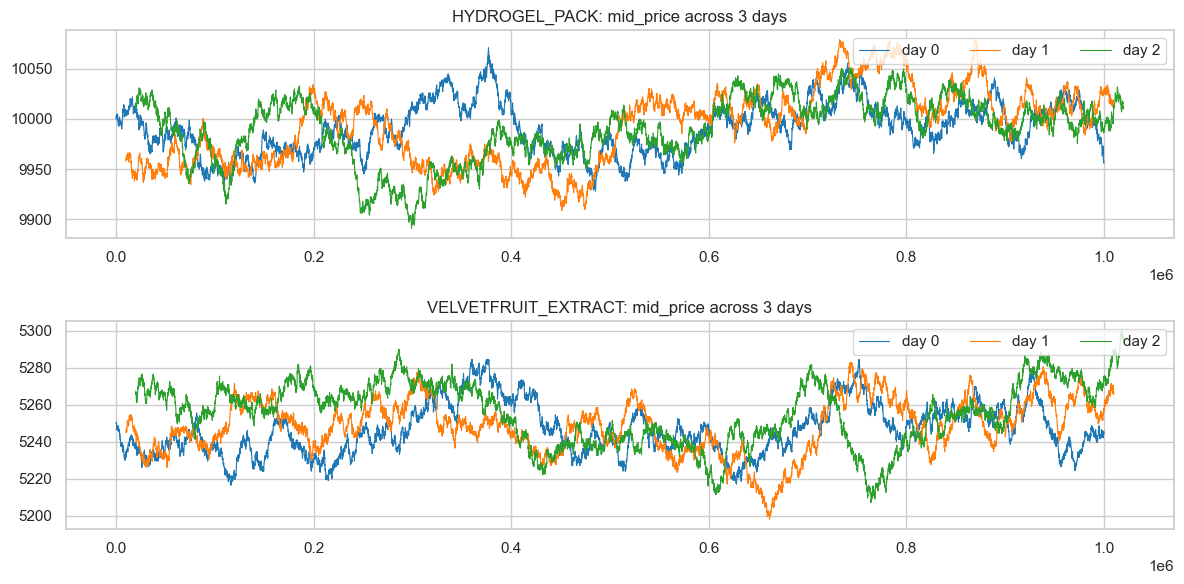

In [5]:
fig, axes = plt.subplots(len(DELTA1_PRODUCTS), 1,
                         figsize=(12, 3 * len(DELTA1_PRODUCTS)), sharex=False)
if len(DELTA1_PRODUCTS) == 1:
    axes = [axes]
for ax, prod in zip(axes, DELTA1_PRODUCTS):
    for d, color in zip(sorted(df_clean["day"].unique()),
                        sns.color_palette("tab10")):
        s = df_clean[(df_clean["product"] == prod) & (df_clean["day"] == d)]
        ax.plot(s["timestamp"].to_numpy() + d * helpers.TIMESTAMPS_PER_DAY,
                s["mid_price"].to_numpy(), color=color, label=f"day {d}", lw=0.8)
    ax.set_title(f"{prod}: mid_price across 3 days")
    ax.legend(loc="upper right", ncol=3)
plt.tight_layout()
plt.show()

### B.3 Per-day OLS drift slope

In [6]:
rows = []
for prod in DELTA1_PRODUCTS:
    for d in sorted(df_clean["day"].unique()):
        s = df_clean[(df_clean["product"] == prod) & (df_clean["day"] == d)].sort_values("timestamp")
        if len(s) < 10:
            continue
        slope, intercept = np.polyfit(s["timestamp"].to_numpy(float),
                                      s["mid_price"].to_numpy(float), 1)
        rows.append({"product": prod, "day": d, "slope_per_tick": slope,
                     "intercept": intercept, "r_points": len(s)})
drift = pd.DataFrame(rows)
display(drift)

,product,day,slope_per_tick,intercept,r_points
0,HYDROGEL_PACK,0,0.000031,9975.297297,10000
1,HYDROGEL_PACK,1,0.000084,9949.870683,10000
2,HYDROGEL_PACK,2,0.000051,9963.979635,10000
3,VELVETFRUIT_EXTRACT,0,0.000013,5239.775550,10000
4,VELVETFRUIT_EXTRACT,1,0.000008,5244.595279,10000
5,VELVETFRUIT_EXTRACT,2,-0.000007,5258.947905,10000


### B.4 Tick-return distribution, autocorrelation, rolling volatility

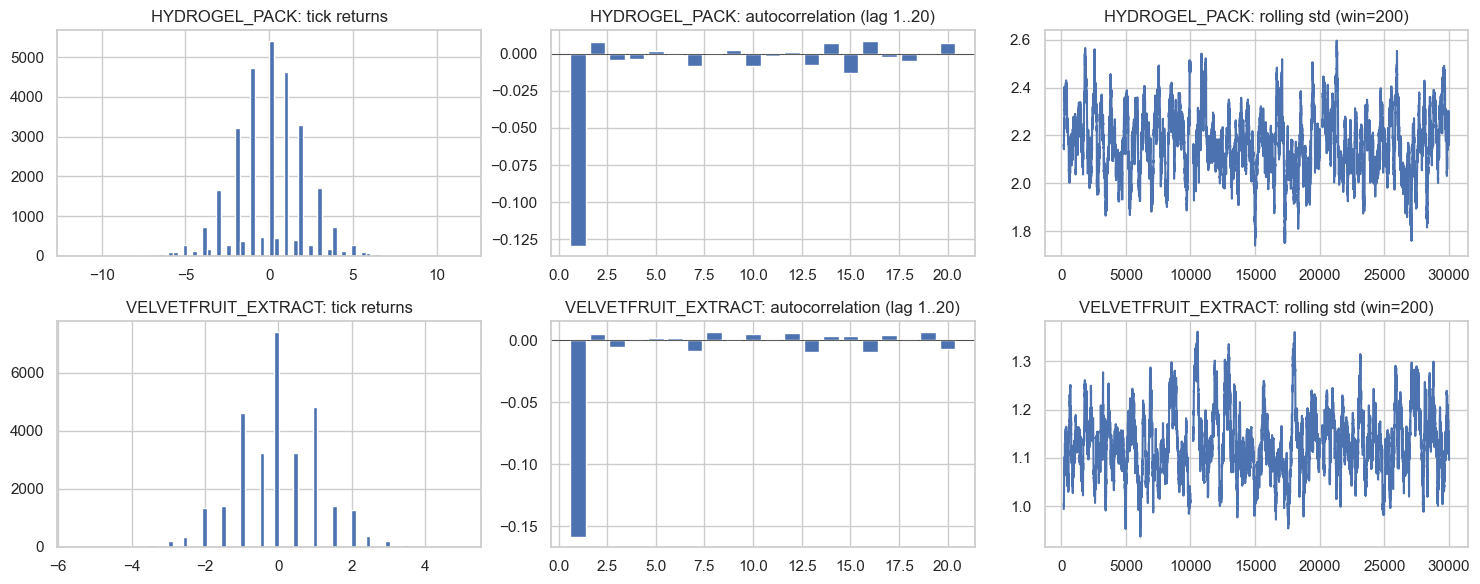

In [7]:
MAX_LAG = 20
ROLL_WIN = 200

fig, axes = plt.subplots(len(DELTA1_PRODUCTS), 3,
                         figsize=(15, 3 * len(DELTA1_PRODUCTS)))
if len(DELTA1_PRODUCTS) == 1:
    axes = axes.reshape(1, -1)

for row, prod in enumerate(DELTA1_PRODUCTS):
    s = df_clean[df_clean["product"] == prod].sort_values(["day", "timestamp"])
    rets = s.groupby("day")["mid_price"].diff()
    axes[row, 0].hist(rets.dropna(), bins=80)
    axes[row, 0].set_title(f"{prod}: tick returns")
    # autocorr
    acf = [rets.autocorr(lag) for lag in range(1, MAX_LAG + 1)]
    axes[row, 1].bar(range(1, MAX_LAG + 1), acf)
    axes[row, 1].axhline(0, color="k", lw=0.5)
    axes[row, 1].set_title(f"{prod}: autocorrelation (lag 1..{MAX_LAG})")
    # rolling vol
    rv = rets.rolling(ROLL_WIN).std()
    axes[row, 2].plot(rv.to_numpy())
    axes[row, 2].set_title(f"{prod}: rolling std (win={ROLL_WIN})")
plt.tight_layout()
plt.show()

### B.5 Cross-product tick-return correlation per day

In [8]:
rows = []
for d in sorted(df_clean["day"].unique()):
    pivot = (df_clean[df_clean["day"] == d]
             .pivot_table(index="timestamp", columns="product", values="mid_price")
             .sort_index())
    rets = pivot.diff().dropna()
    if rets.shape[1] < 2:
        continue
    rows.append({
        "day": d,
        "corr": helpers.safe_corr(rets[DELTA1_PRODUCTS[0]], rets[DELTA1_PRODUCTS[1]]),
        "n": len(rets),
    })
display(pd.DataFrame(rows))

,day,corr,n
0,0,0.011119,9999
1,1,0.012005,9999
2,2,-0.004981,9999
